In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, pointbiserialr, mannwhitneyu
import warnings
warnings.filterwarnings("ignore")

# Plot style
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 5)})

# Load
df = pd.read_csv("manufacturing.csv")
df.drop(columns=["Unnamed: 0"], inplace=True)

# Binary anomaly flag (1 = any breakdown, 0 = none)
df["BREAKDOWN"] = (df["BREAKS"] > 0).astype(int)

print(f"Dataset shape : {df.shape}")
print(f"\nBREAKS distribution:\n{df['BREAKS'].value_counts().sort_index()}")
print(f"\nBreakdown rate: {df['BREAKDOWN'].mean()*100:.1f}%")



Dataset shape : (17600, 24)

BREAKS distribution:
BREAKS
0    12332
1     4199
2     1054
3       15
Name: count, dtype: int64

Breakdown rate: 29.9%


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().sum()

,0
ID,0
Priority,0
Family_type,0
First_stage,0
Start_time_S1,0
Finish_time_S1,0
Processing_Time_S1,0
Second_stage,0
Start_time_S2,0
Finish_Time_S2,0


In [ ]:
df[df.duplicated()]


,ID,Priority,Family_type,First_stage,Start_time_S1,Finish_time_S1,Processing_Time_S1,Second_stage,Start_time_S2,Finish_Time_S2,...,Processing_Time_S3,Fourth_stage,Start_time_s4,Finish_time,Processing_Time_S4,Overall_processing_time,Overall_waiting_time,Tardiness,BREAKS,BREAKDOWN
160,12,1,34,SMD_0,0,402,402,AOI_2,402,781,...,0,CC_1,781,979,198,979,0,0,0,0
161,23,1,37,SMD_1,0,354,354,AOI_0,354,441,...,151,CC_1,592,696,104,696,0,0,0,0
162,131,1,29,SMD_3,0,37,37,AOI_0,37,90,...,48,0,0,0,0,138,0,0,0,0
164,75,1,20,SMD_4,0,189,189,AOI_1,189,766,...,255,0,0,0,0,1021,0,0,0,0
165,78,1,29,SMD_3,37,172,135,AOI_0,172,230,...,109,0,0,0,0,302,37,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17521,109,10,37,SMD_1,475,1159,684,AOI_3,1159,1282,...,379,CC_0,1776,1872,96,1282,590,0,0,0
17522,111,10,28,SMD_2,982,1259,277,AOI_4,1259,1490,...,119,CC_1,1609,1682,73,700,982,0,0,0
17539,104,12,18,SMD_0,1155,1516,361,AOI_4,1516,1661,...,336,CC_0,2485,2543,58,900,1643,0,0,0
17557,102,14,18,SMD_0,1516,2504,988,AOI_1,2504,2699,...,670,0,0,0,0,1853,1516,0,0,0


In [ ]:
df[df['ID']==12]

,ID,Priority,Family_type,First_stage,Start_time_S1,Finish_time_S1,Processing_Time_S1,Second_stage,Start_time_S2,Finish_Time_S2,...,Processing_Time_S3,Fourth_stage,Start_time_s4,Finish_time,Processing_Time_S4,Overall_processing_time,Overall_waiting_time,Tardiness,BREAKS,BREAKDOWN
0,12,1,34,SMD_0,0,402,402,AOI_2,402,781,...,0,CC_1,781,979,198,979,0,0,0,0
160,12,1,34,SMD_0,0,402,402,AOI_2,402,781,...,0,CC_1,781,979,198,979,0,0,0,0
320,12,1,34,SMD_0,0,402,402,AOI_2,402,781,...,0,CC_1,781,979,198,979,0,0,0,0
480,12,1,34,SMD_0,0,402,402,AOI_2,402,781,...,0,CC_1,781,979,198,979,0,0,0,0
640,12,1,34,SMD_0,0,402,402,AOI_2,402,781,...,0,CC_1,781,979,198,979,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16800,12,1,34,SMD_0,0,402,402,AOI_2,402,781,...,0,CC_1,781,979,198,979,0,0,0,0
16960,12,1,34,SMD_0,0,402,402,AOI_2,402,781,...,0,CC_1,781,979,198,979,0,0,0,0
17120,12,1,34,SMD_0,0,402,402,AOI_2,402,781,...,0,CC_1,781,979,198,979,0,0,0,0
17280,12,1,34,SMD_0,0,402,402,AOI_2,402,781,...,0,CC_1,781,979,198,979,0,0,0,0


In [ ]:
df.drop_duplicates(inplace=True)
print(f"DataFrame shape after removing duplicates: {df.shape}")

DataFrame shape after removing duplicates: (14507, 24)


In [ ]:
# ─────────────────────────────────────────────────────────────
# STEP 1 — STATISTICAL SUMMARY
# ─────────────────────────────────────────────────────────────
numeric_cols = [
    "Priority", "Family_type",
    "Processing_Time_S1", "Processing_Time_S2",
    "Processing_Time_S3", "Processing_Time_S4",
    "Overall_processing_time", "Overall_waiting_time", "Tardiness"
]

print("\n=== DESCRIPTIVE STATISTICS ===")
desc = df[numeric_cols].describe().T
desc["skewness"] = df[numeric_cols].skew()
desc["kurtosis"] = df[numeric_cols].kurt()
desc["IQR"]      = df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25)
desc["CV%"]      = (df[numeric_cols].std() / df[numeric_cols].mean() * 100).round(1)
print(desc.round(2).to_string())

# Shapiro-Wilk normality test (on a sample — test is slow on N>5000)
print("\n=== NORMALITY (Shapiro-Wilk, n=500 sample) ===")
sample = df[numeric_cols].sample(500, random_state=42)
for col in numeric_cols:
    stat, p = stats.shapiro(sample[col].dropna())
    print(f"  {col:<30} W={stat:.4f}  p={p:.4e}  {'NORMAL' if p>0.05 else 'NOT normal'}")




=== DESCRIPTIVE STATISTICS ===
                           count     mean      std    min     25%     50%      75%      max  skewness  kurtosis     IQR    CV%
Priority                 14507.0    11.24     4.69    1.0     8.0    11.0     15.0     19.0     -0.06     -1.07     7.0   41.7
Family_type              14507.0    18.49    11.21    1.0     9.0    18.0     27.0     40.0      0.22     -1.09    18.0   60.6
Processing_Time_S1       14507.0   553.81   461.28   37.0   144.0   390.0    909.0   1871.0      0.87     -0.09   765.0   83.3
Processing_Time_S2       14507.0   471.98   458.78   40.0   100.0   263.0    843.0   1932.0      1.12      0.33   743.0   97.2
Processing_Time_S3       14507.0   411.83   421.74    0.0    77.0   253.0    724.0   1666.0      1.11      0.39   647.0  102.4
Processing_Time_S4       14507.0   156.92   226.13    0.0     0.0    78.0    176.0   1563.0      2.58      7.38   176.0  144.1
Overall_processing_time  14507.0  1594.53  1175.52  126.0   509.0  1244.0   258

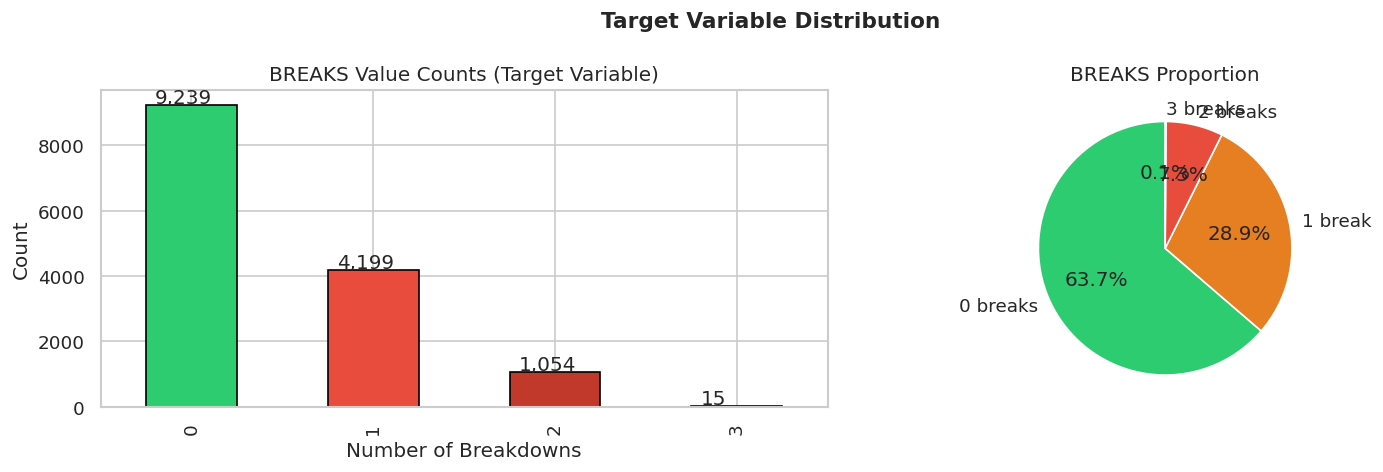

→ Saved: 01_target_distribution.png


In [ ]:
# ─────────────────────────────────────────────────────────────
# STEP 2 — UNIVARIATE ANALYSIS
# ─────────────────────────────────────────────────────────────

# 2a — Distribution of BREAKS (target)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df["BREAKS"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color=["#2ecc71","#e74c3c","#c0392b","#922b21"], edgecolor="black"
)
axes[0].set_title("BREAKS Value Counts (Target Variable)")
axes[0].set_xlabel("Number of Breakdowns"); axes[0].set_ylabel("Count")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}", (p.get_x()+0.05, p.get_height()+50))

axes[1].pie(
    df["BREAKS"].value_counts().sort_index(),
    labels=["0 breaks","1 break","2 breaks","3 breaks"],
    autopct="%1.1f%%", startangle=90,
    colors=["#2ecc71","#e67e22","#e74c3c","#922b21"]
)
axes[1].set_title("BREAKS Proportion")
plt.suptitle("Target Variable Distribution", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig("01_target_distribution.png", bbox_inches="tight")
plt.show()
print("→ Saved: 01_target_distribution.png")

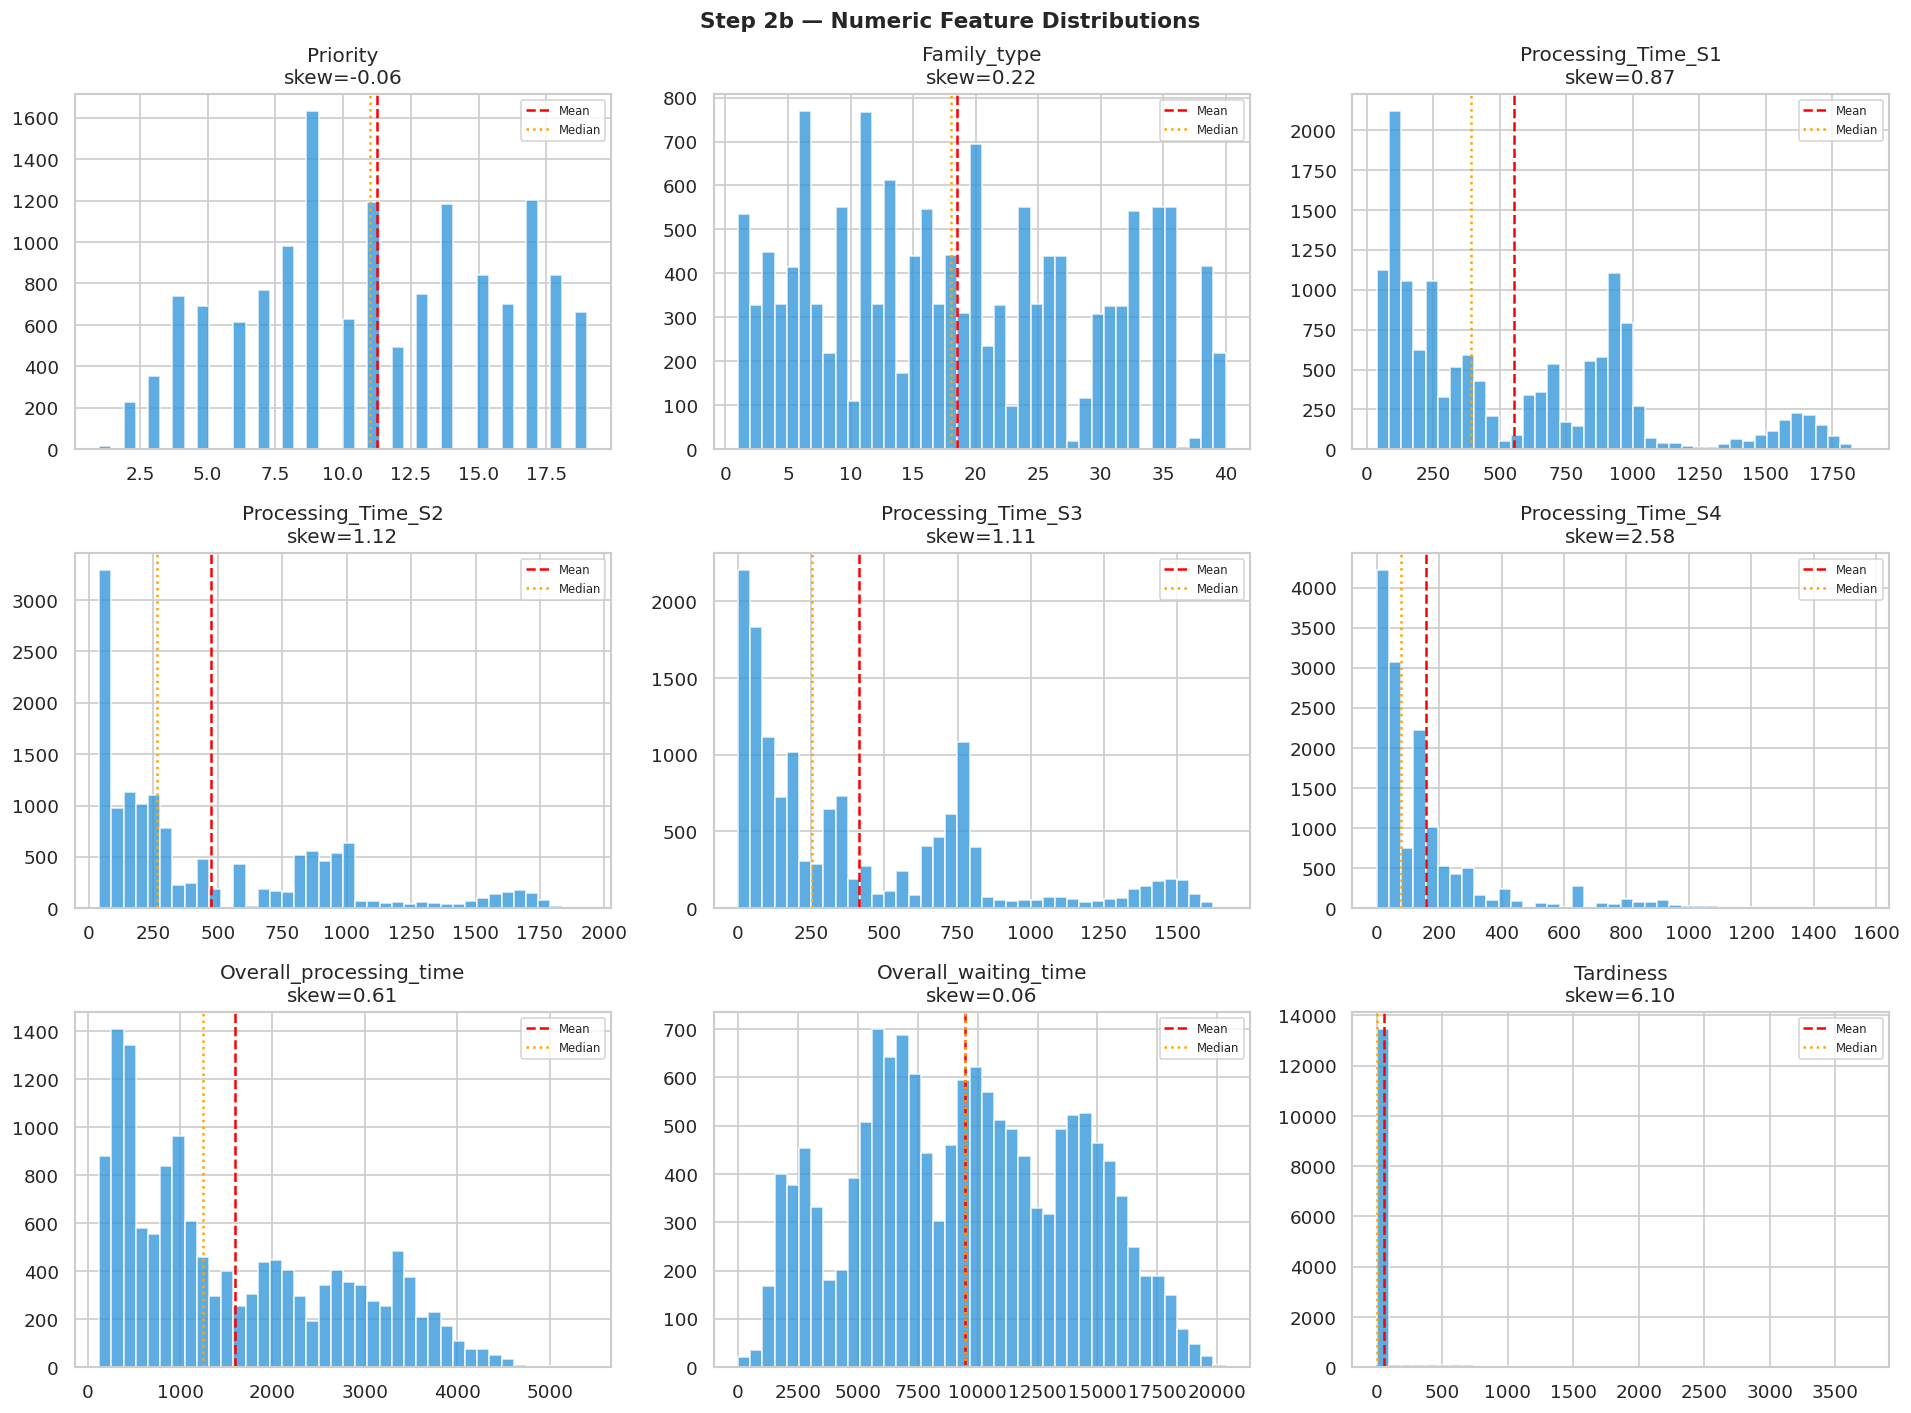

→ Saved: 02_univariate_distributions.png


In [ ]:
# 2b — Numeric feature distributions
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=40, color="#3498db", edgecolor="white", alpha=0.8)
    axes[i].axvline(df[col].mean(),   color="red",    linestyle="--", label="Mean")
    axes[i].axvline(df[col].median(), color="orange", linestyle=":",  label="Median")
    axes[i].set_title(f"{col}\nskew={df[col].skew():.2f}")
    axes[i].legend(fontsize=7)
plt.suptitle("Step 2b — Numeric Feature Distributions", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig("02_univariate_distributions.png", bbox_inches="tight")
plt.show()
print("→ Saved: 02_univariate_distributions.png")

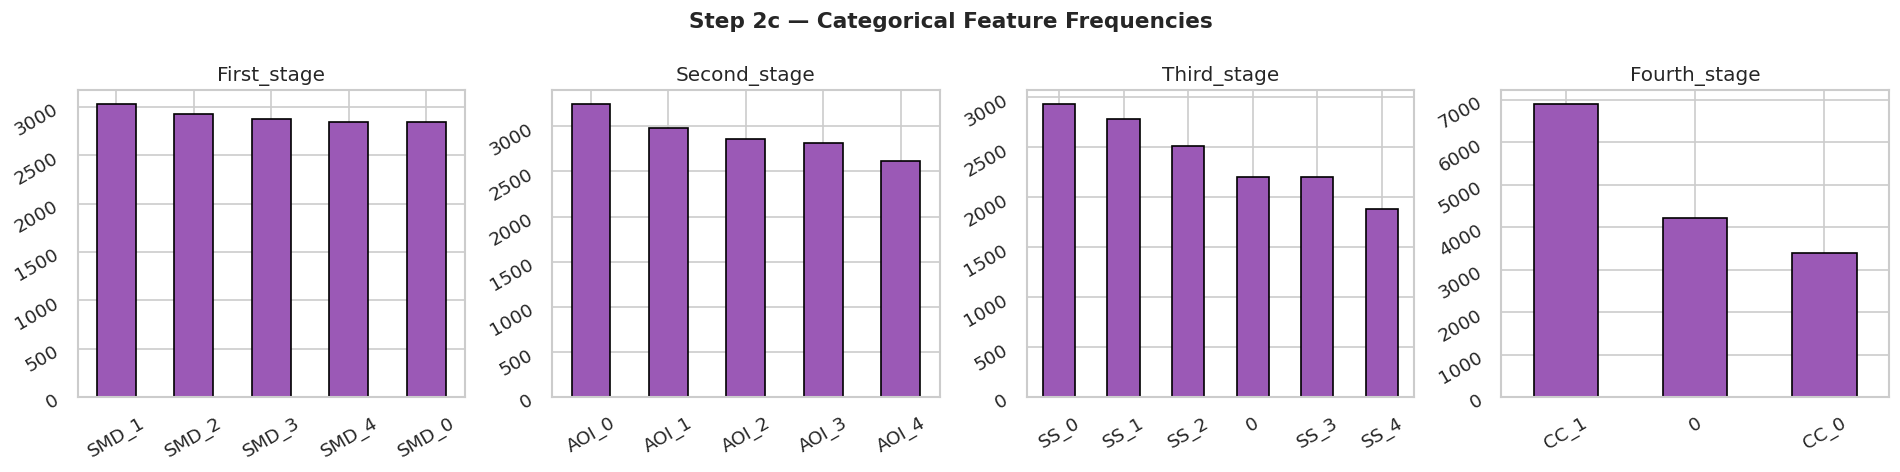

→ Saved: 03_categorical_distributions.png


In [ ]:
# 2c — Categorical columns
cat_cols = ["First_stage", "Second_stage", "Third_stage", "Fourth_stage"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(cat_cols):
    vc = df[col].value_counts()
    vc.plot(kind="bar", ax=axes[i], color="#9b59b6", edgecolor="black")
    axes[i].set_title(col); axes[i].set_xlabel(""); axes[i].tick_params(rotation=30)
plt.suptitle("Step 2c — Categorical Feature Frequencies", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig("03_categorical_distributions.png", bbox_inches="tight")
plt.show()
print("→ Saved: 03_categorical_distributions.png")





=== IQR OUTLIER COUNT PER FEATURE ===
  Priority                      :     0 outliers (0.0%)
  Family_type                   :     0 outliers (0.0%)
  Processing_Time_S1            :     0 outliers (0.0%)
  Processing_Time_S2            :     0 outliers (0.0%)
  Processing_Time_S3            :     0 outliers (0.0%)
  Processing_Time_S4            :  1233 outliers (8.5%)
  Overall_processing_time       :     0 outliers (0.0%)
  Overall_waiting_time          :     0 outliers (0.0%)
  Tardiness                     :  1122 outliers (7.7%)


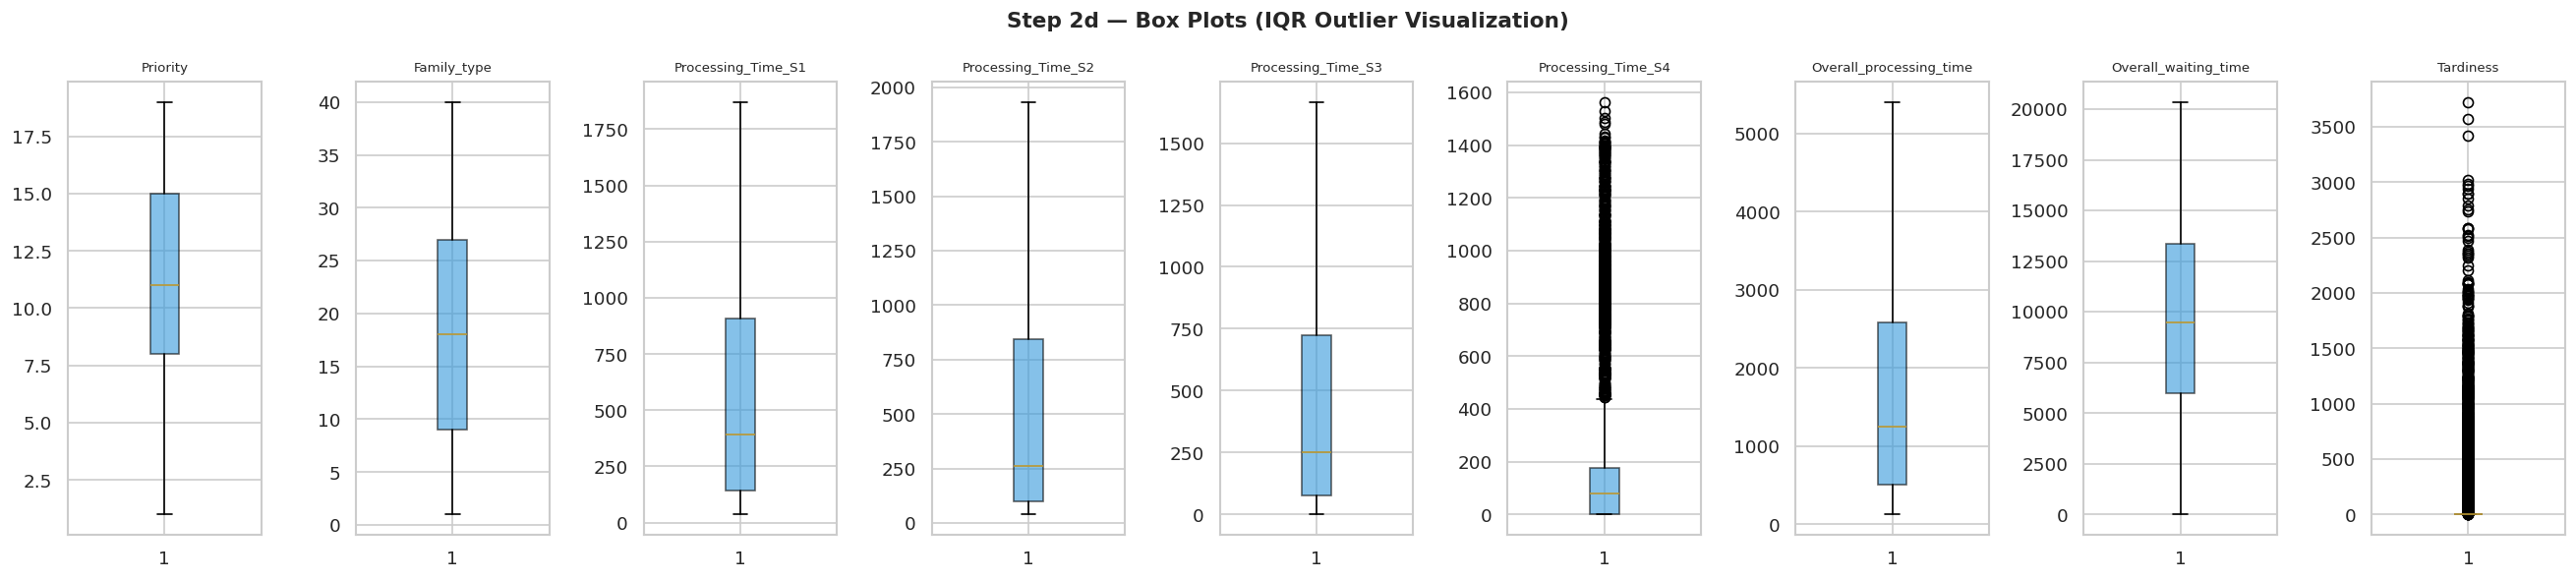

→ Saved: 04_boxplots.png


In [ ]:
# 2d — Box plots & outlier detection via IQR
print("\n=== IQR OUTLIER COUNT PER FEATURE ===")
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(22, 5))
for i, col in enumerate(numeric_cols):
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f"  {col:<30}: {n_out:5d} outliers ({n_out/len(df)*100:.1f}%)")
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor="#3498db", alpha=0.6))
    axes[i].set_title(col, fontsize=8); axes[i].set_xlabel("")
plt.suptitle("Step 2d — Box Plots (IQR Outlier Visualization)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig("04_boxplots.png", bbox_inches="tight")
plt.show()
print("→ Saved: 04_boxplots.png")

Based on the p-values:

Highly Significant Differences (p < 0.001 - marked with ***): Priority, Processing_Time_S1, Processing_Time_S2, Processing_Time_S3, Processing_Time_S4, Overall_processing_time, and Tardiness all show a very strong statistical difference between the 'no breakdown' and 'breakdown' groups. This suggests these factors are highly correlated with the occurrence of breakdowns.

No Significant Difference (p > 0.05 - marked with ns): Family_type and Overall_waiting_time do not show a statistically significant difference between the two groups. This means that, based on this test, these features are unlikely to be strong predictors of breakdowns.

In summary, most of the processing time metrics, priority, and tardiness are strongly associated with breakdowns, while family type and overall waiting time are not.



=== NUMERIC vs BREAKDOWN — Mann-Whitney U Test ===
  Priority                       U=22232182  p=3.5789e-18  ***
  Family_type                    U=24600584  p=2.7425e-01  ns
  Processing_Time_S1             U=9286676  p=0.0000e+00  ***
  Processing_Time_S2             U=8924092  p=0.0000e+00  ***
  Processing_Time_S3             U=9783916  p=0.0000e+00  ***
  Processing_Time_S4             U=16216988  p=9.5540e-252  ***
  Overall_processing_time        U=3871832  p=0.0000e+00  ***
  Overall_waiting_time           U=24645427  p=2.0141e-01  ns
  Tardiness                      U=21617355  p=2.7044e-129  ***


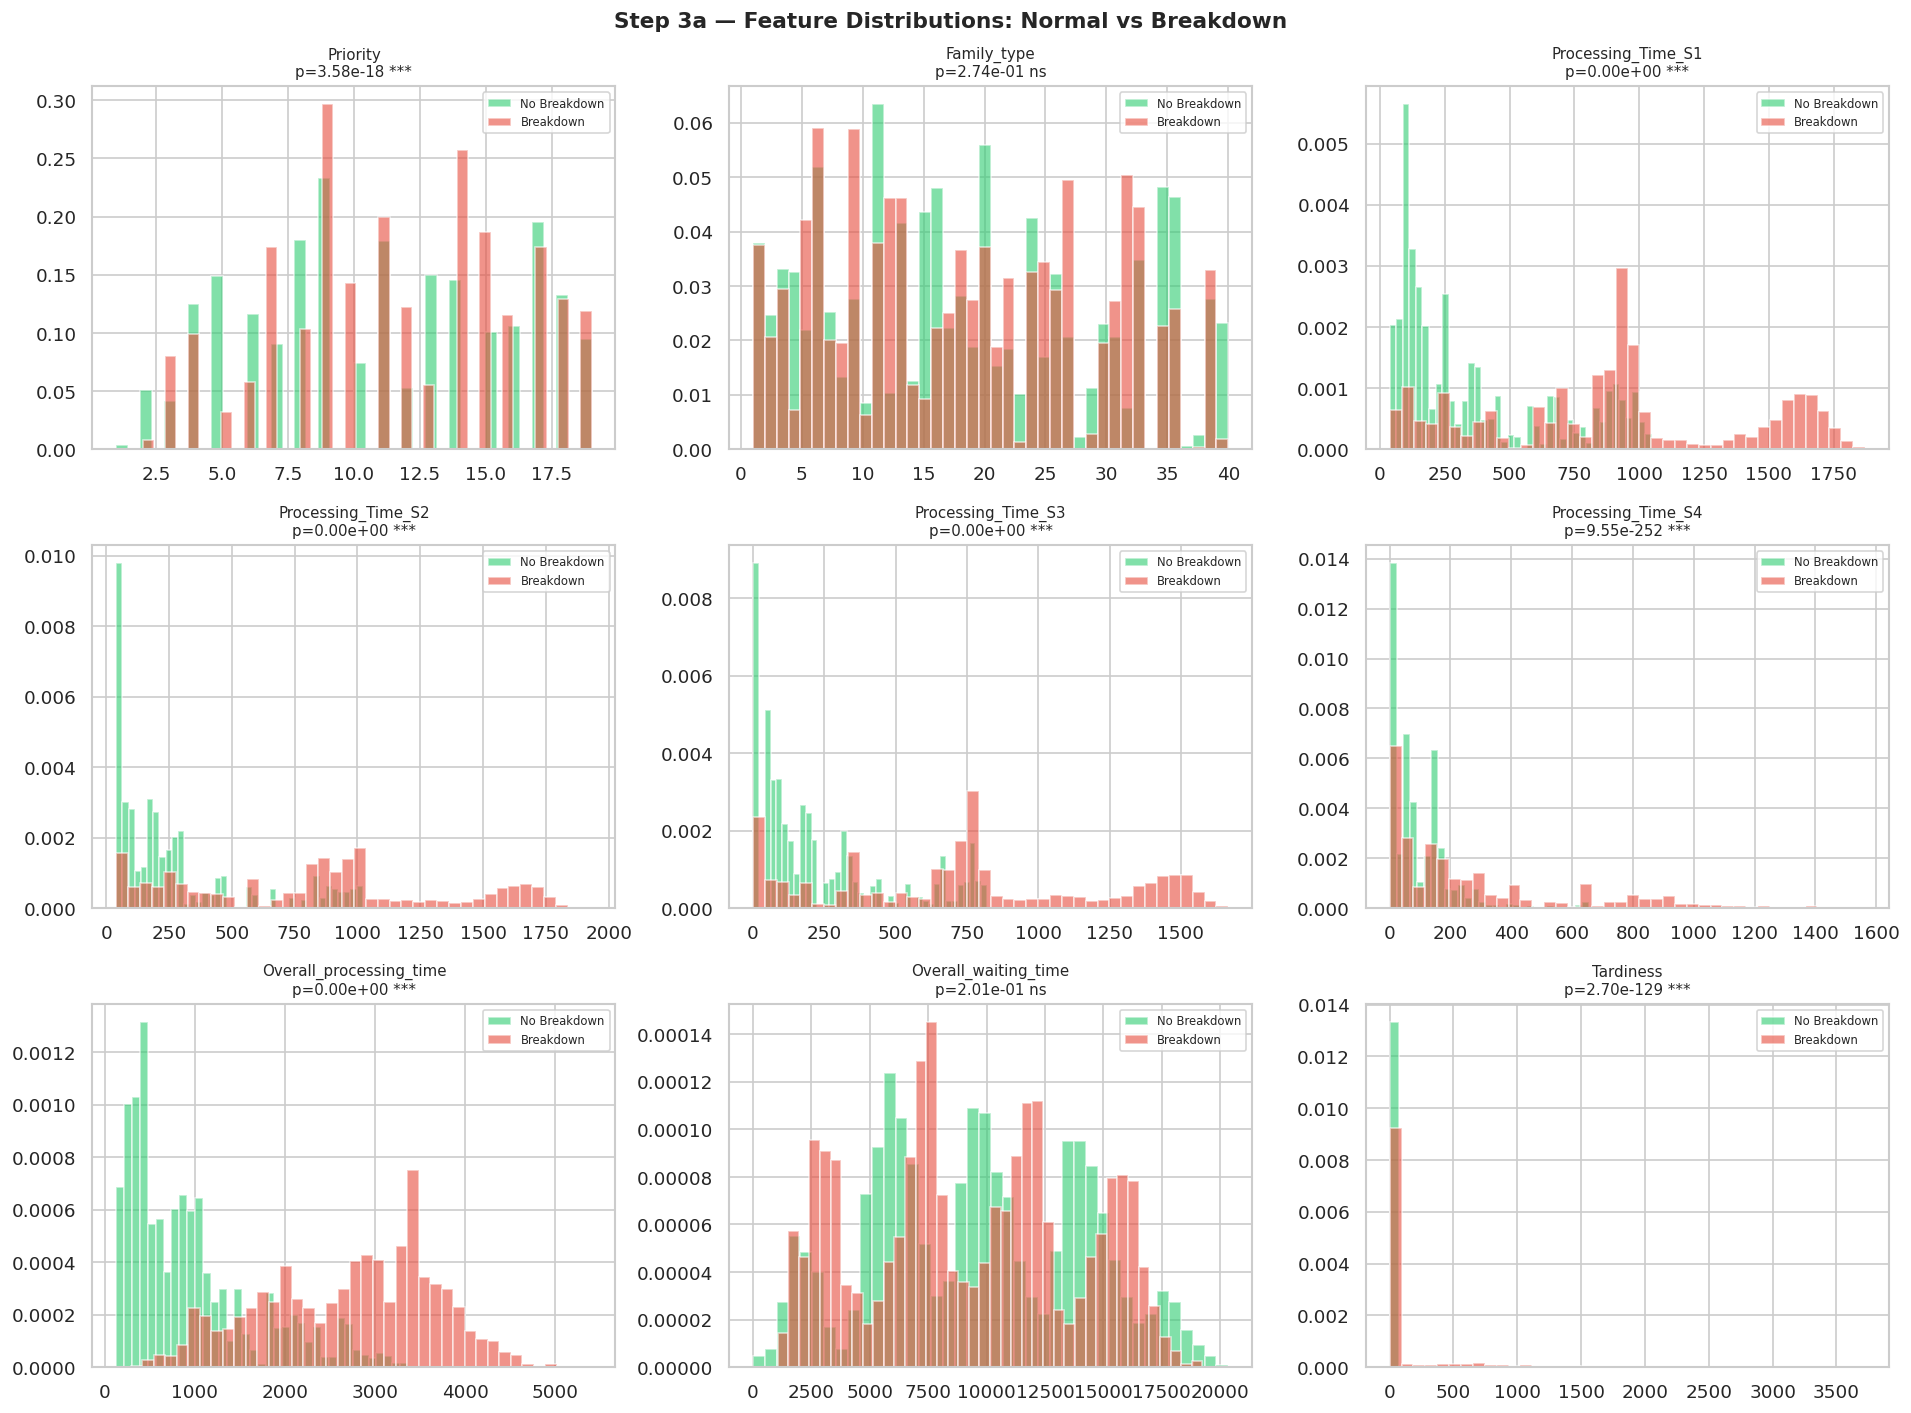

→ Saved: 05_bivariate_numeric.png


In [ ]:
# 3a — Numeric features vs BREAKDOWN (Mann-Whitney U test)
print("\n=== NUMERIC vs BREAKDOWN — Mann-Whitney U Test ===")
normal   = df[df["BREAKDOWN"] == 0]
anomaly  = df[df["BREAKDOWN"] == 1]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    u_stat, p_val = mannwhitneyu(normal[col], anomaly[col], alternative="two-sided")
    sig = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else "ns"))
    print(f"  {col:<30} U={u_stat:.0f}  p={p_val:.4e}  {sig}")

    axes[i].hist(normal[col],  bins=40, alpha=0.6, label="No Breakdown", color="#2ecc71", density=True)
    axes[i].hist(anomaly[col], bins=40, alpha=0.6, label="Breakdown",    color="#e74c3c", density=True)
    axes[i].set_title(f"{col}\np={p_val:.2e} {sig}", fontsize=9)
    axes[i].legend(fontsize=7)
plt.suptitle("Step 3a — Feature Distributions: Normal vs Breakdown", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig("05_bivariate_numeric.png", bbox_inches="tight")
plt.show()
print("→ Saved: 05_bivariate_numeric.png")



=== POINT-BISERIAL CORRELATION (numeric vs BREAKDOWN) ===
  Priority                      : r=+0.0717  p=5.4272e-18  ***
  Family_type                   : r=-0.0124  p=1.3608e-01  ns
  Processing_Time_S1            : r=+0.5585  p=0.0000e+00  ***
  Processing_Time_S2            : r=+0.5729  p=0.0000e+00  ***
  Processing_Time_S3            : r=+0.5694  p=0.0000e+00  ***
  Processing_Time_S4            : r=+0.3824  p=0.0000e+00  ***
  Overall_processing_time       : r=+0.7206  p=0.0000e+00  ***
  Overall_waiting_time          : r=-0.0260  p=1.7565e-03  **
  Tardiness                     : r=+0.1841  p=9.8027e-111  ***


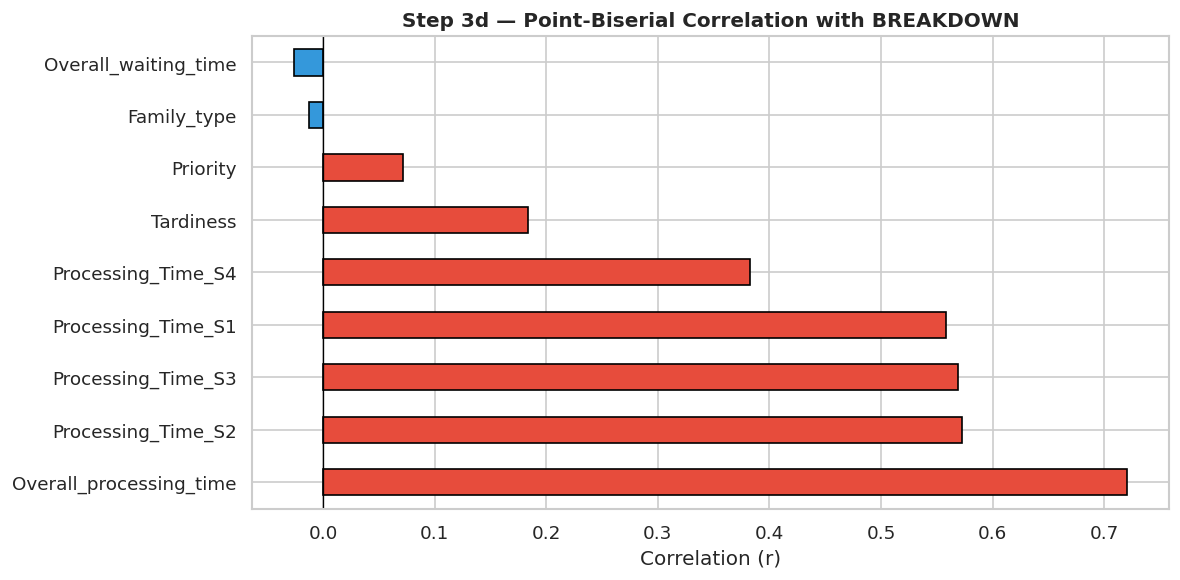

→ Saved: 08_point_biserial.png


In [ ]:

# 3d — Point-Biserial Correlation (numeric vs binary BREAKDOWN)
print("\n=== POINT-BISERIAL CORRELATION (numeric vs BREAKDOWN) ===")
correlations = {}
for col in numeric_cols:
    r, p = pointbiserialr(df["BREAKDOWN"], df[col])
    correlations[col] = {"r": r, "p": p}
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    print(f"  {col:<30}: r={r:+.4f}  p={p:.4e}  {sig}")

corr_df = pd.DataFrame(correlations).T.sort_values("r", ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#e74c3c" if r > 0 else "#3498db" for r in corr_df["r"]]
corr_df["r"].plot(kind="barh", ax=ax, color=colors, edgecolor="black")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Step 3d — Point-Biserial Correlation with BREAKDOWN", fontsize=12, fontweight="bold")
ax.set_xlabel("Correlation (r)")
plt.tight_layout(); plt.savefig("08_point_biserial.png", bbox_inches="tight")
plt.show()
print("→ Saved: 08_point_biserial.png")

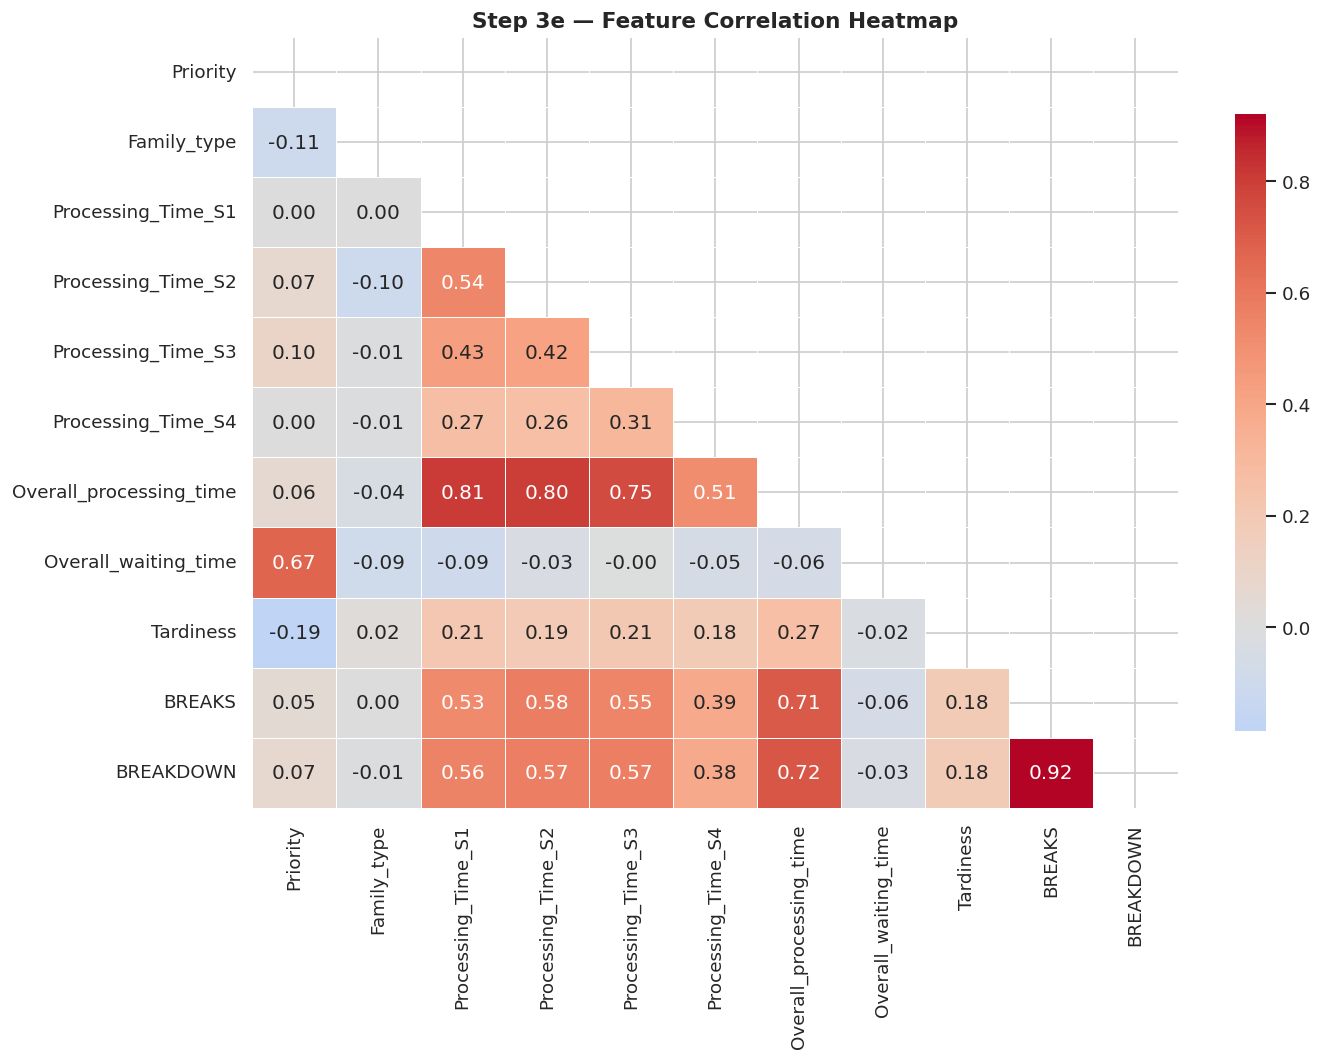

→ Saved: 09_correlation_heatmap.png


In [ ]:
# 3e — Correlation Heatmap (numeric features)
fig, ax = plt.subplots(figsize=(12, 9))
corr_matrix = df[numeric_cols + ["BREAKS", "BREAKDOWN"]].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title("Step 3e — Feature Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig("09_correlation_heatmap.png", bbox_inches="tight")
plt.show()
print("→ Saved: 09_correlation_heatmap.png")
